# Notebook 01: Introduction to Reinforcement Learning

**Author:** Milan Amrut Joshi
**Series:** Reinforcement Learning Basics (1/20)

---

## 1. What is Reinforcement Learning?

**Reinforcement Learning (RL)** is a branch of machine learning where an **agent** learns to make decisions by interacting with an **environment** to maximize **cumulative reward**.

### The Three Paradigms of Machine Learning

| Paradigm | Data | Signal | Example |
|----------|------|--------|---------|
| **Supervised Learning** | Labeled $(x, y)$ pairs | Correct answer | Image classification |
| **Unsupervised Learning** | Unlabeled $x$ | Structure/patterns | Clustering |
| **Reinforcement Learning** | States, actions, rewards | Reward signal (delayed) | Game playing, robotics |

**Key difference:** In RL, there is no supervisor — only a **reward signal** that may be **delayed**. The agent must discover which actions yield the most reward through **trial and error**.

## 2. The RL Framework

The agent-environment interaction loop:

```
Agent ──action a_t──> Environment
  ^                      |
  |                      v
  <──state s_{t+1}, reward r_{t+1}──
```

### Core Components

| Symbol | Name | Definition |
|--------|------|------------|
| $\mathcal{S}$ | **State space** | Set of all possible states |
| $\mathcal{A}$ | **Action space** | Set of all possible actions |
| $R$ | **Reward function** | $R: \mathcal{S} \times \mathcal{A} \times \mathcal{S} \to \mathbb{R}$ |
| $P$ | **Transition function** | $P(s'|s,a) = \Pr[S_{t+1}=s'|S_t=s, A_t=a]$ |
| $\gamma$ | **Discount factor** | $\gamma \in [0, 1]$ — weights future rewards |
| $\pi$ | **Policy** | $\pi(a|s) = \Pr[A_t=a|S_t=s]$ — agent's strategy |

### The Interaction Loop

At each time step $t$:
1. Agent observes state $S_t \in \mathcal{S}$
2. Agent selects action $A_t \sim \pi(\cdot|S_t)$
3. Environment transitions to $S_{t+1} \sim P(\cdot|S_t, A_t)$
4. Agent receives reward $R_{t+1} = R(S_t, A_t, S_{t+1})$

## 3. The Reward Hypothesis

> **"All of what we mean by goals and purposes can be well thought of as the maximization of the expected value of the cumulative sum of a received scalar signal (called reward)."**
> — Sutton & Barto

This is the foundational assumption of RL: any goal can be expressed as maximizing expected cumulative reward.

### Return (Cumulative Reward)

The **return** $G_t$ is the total discounted reward from time step $t$:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

### Why Discount? ($\gamma < 1$)

1. **Mathematical convergence:** Ensures $G_t < \infty$ for bounded rewards: $G_t \leq \frac{R_{\max}}{1 - \gamma}$
2. **Uncertainty:** Future rewards are less certain
3. **Immediate preference:** A reward now is worth more than the same reward later
4. **Avoids infinite returns** in continuing (non-episodic) tasks

| $\gamma$ | Behavior |
|-----------|----------|
| $\gamma = 0$ | **Myopic** — only cares about immediate reward |
| $\gamma = 1$ | **Far-sighted** — all rewards equally important |
| $\gamma = 0.99$ | Typical — balances short and long term |

## 4. Episodes vs Continuing Tasks

### Episodic Tasks
- Have a natural **terminal state** (end of game, end of episode)
- Return: $G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$ where $T$ is the terminal time
- Examples: Chess game, maze navigation, Atari games

### Continuing Tasks
- Go on **forever** — no terminal state
- Must use $\gamma < 1$ to keep return finite
- Examples: Robot control, stock trading, temperature regulation

## 5. Types of RL

| Criterion | Type A | Type B |
|-----------|--------|--------|
| **Model knowledge** | **Model-Based** (knows $P, R$) | **Model-Free** (learns from experience) |
| **What to learn** | **Value-Based** (learn $V$ or $Q$) | **Policy-Based** (learn $\pi$ directly) |
| **Data source** | **On-Policy** (learn from own policy) | **Off-Policy** (learn from other policy) |

## 6. Historical Timeline

| Year | Milestone |
|------|-----------|
| 1950s | **Bellman** — Dynamic Programming, Bellman Equation |
| 1972 | **Klopf** — Trial-and-error learning in adaptive systems |
| 1988 | **Sutton** — Temporal Difference learning |
| 1989 | **Watkins** — Q-Learning |
| 1992 | **Tesauro** — TD-Gammon (backgammon) |
| 1998 | **Sutton & Barto** — RL: An Introduction (1st edition) |
| 2013 | **Mnih et al.** — DQN plays Atari |
| 2016 | **Silver et al.** — AlphaGo defeats Lee Sedol |
| 2017 | **Schulman et al.** — PPO |
| 2019 | **OpenAI Five** — Dota 2 |
| 2022 | **InstructGPT/ChatGPT** — RLHF for language models |

Random agent over 1000 episodes:
  Mean steps: 18.3
  Min steps:  1
  Max steps:  100


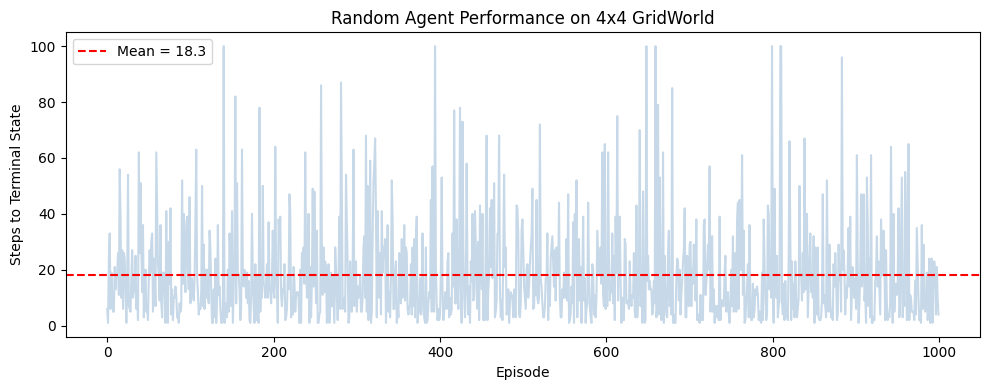

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Simple Grid World Environment from Scratch
# ============================================

class GridWorld:
    """
    4x4 Grid World.
    States: 0-15 (4x4 grid)
    Actions: 0=up, 1=right, 2=down, 3=left
    Terminal states: 0 (top-left) and 15 (bottom-right)
    Reward: -1 for every step (encourages shortest path)
    """
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.terminal_states = [0, self.n_states - 1]
        self.state = None

    def reset(self):
        # Start in a random non-terminal state
        while True:
            self.state = np.random.randint(self.n_states)
            if self.state not in self.terminal_states:
                break
        return self.state

    def step(self, action):
        if self.state in self.terminal_states:
            return self.state, 0, True

        row, col = divmod(self.state, self.size)

        if action == 0:    # up
            row = max(0, row - 1)
        elif action == 1:  # right
            col = min(self.size - 1, col + 1)
        elif action == 2:  # down
            row = min(self.size - 1, row + 1)
        elif action == 3:  # left
            col = max(0, col - 1)

        self.state = row * self.size + col
        reward = -1
        done = self.state in self.terminal_states
        return self.state, reward, done

    def render(self):
        grid = np.full((self.size, self.size), '.')
        row, col = divmod(self.state, self.size)
        grid[row, col] = 'A'
        grid[0, 0] = 'T'
        grid[self.size-1, self.size-1] = 'T'
        if self.state in self.terminal_states:
            row, col = divmod(self.state, self.size)
            grid[row, col] = 'X'
        for r in grid:
            print(' '.join(r))
        print()

# --- Run a random agent ---
env = GridWorld(size=4)
n_episodes = 1000
episode_lengths = []

for ep in range(n_episodes):
    state = env.reset()
    steps = 0
    done = False
    while not done and steps < 100:
        action = np.random.randint(env.n_actions)  # random policy
        state, reward, done = env.step(action)
        steps += 1
    episode_lengths.append(steps)

print(f"Random agent over {n_episodes} episodes:")
print(f"  Mean steps: {np.mean(episode_lengths):.1f}")
print(f"  Min steps:  {np.min(episode_lengths)}")
print(f"  Max steps:  {np.max(episode_lengths)}")

# Visualize episode lengths
plt.figure(figsize=(10, 4))
plt.plot(episode_lengths, alpha=0.3, color='steelblue')
plt.axhline(np.mean(episode_lengths), color='red', linestyle='--', label=f'Mean = {np.mean(episode_lengths):.1f}')
plt.xlabel('Episode')
plt.ylabel('Steps to Terminal State')
plt.title('Random Agent Performance on 4x4 GridWorld')
plt.legend()
plt.tight_layout()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:13: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Milan Amrut Joshi\AppData\Local\Temp\ipykernel_58252\2372240065.py:9: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(cumulative, label=f'$\gamma$ = {gamma}', linewidth=2)
C:\Users\Milan Amrut Joshi\AppData\Local\Temp\ipykernel_58252\2372240065.py:13: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Effect of Discount Factor $\gamma$ on Return')


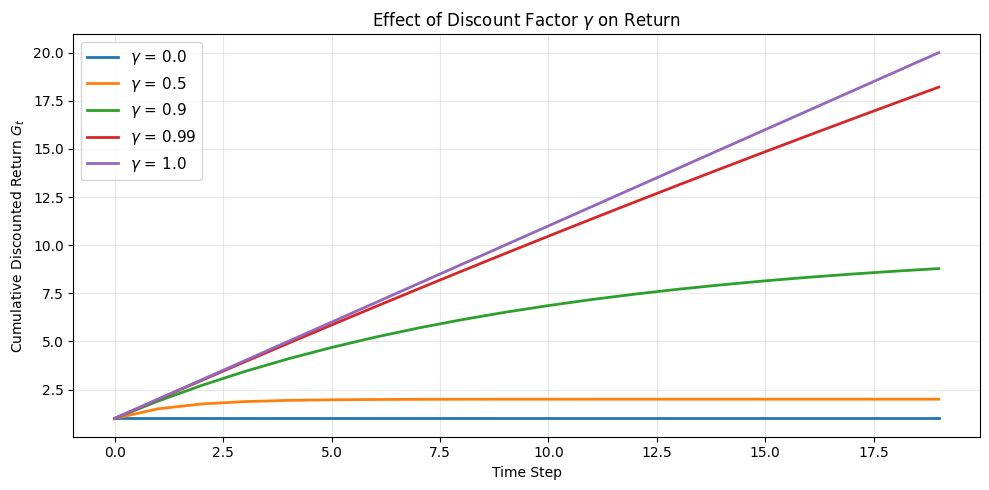

Theoretical max return G = R_max / (1 - gamma):
  gamma=0.5: G_max = 1/(1-0.5) = 2.0
  gamma=0.9: G_max = 1/(1-0.9) = 10.0
  gamma=0.95: G_max = 1/(1-0.95) = 20.0
  gamma=0.99: G_max = 1/(1-0.99) = 100.0


In [2]:
# --- Demonstrate the discount factor effect ---
gamma_values = [0.0, 0.5, 0.9, 0.99, 1.0]
rewards = [1] * 20  # constant reward of 1 for 20 steps

plt.figure(figsize=(10, 5))
for gamma in gamma_values:
    discounted = [gamma**k * r for k, r in enumerate(rewards)]
    cumulative = np.cumsum(discounted)
    plt.plot(cumulative, label=f'$\gamma$ = {gamma}', linewidth=2)

plt.xlabel('Time Step')
plt.ylabel('Cumulative Discounted Return $G_t$')
plt.title('Effect of Discount Factor $\gamma$ on Return')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show that G_t converges for gamma < 1
print("Theoretical max return G = R_max / (1 - gamma):")
for gamma in [0.5, 0.9, 0.95, 0.99]:
    print(f"  gamma={gamma}: G_max = 1/(1-{gamma}) = {1/(1-gamma):.1f}")

## Summary

| Concept | Key Formula |
|---------|------------|
| **Return** | $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$ |
| **Policy** | $\pi(a|s) = \Pr[A_t = a | S_t = s]$ |
| **Transition** | $P(s'|s,a) = \Pr[S_{t+1}=s'|S_t=s, A_t=a]$ |
| **Goal** | Maximize $\mathbb{E}_\pi[G_t]$ |

**Next:** Notebook 02 — Markov Decision Processes (MDPs)